In [1]:
# Homework 1 Problem 1 - Modified AlexNet on CIFAR-10
# Name: Viprav Lipare
# Student ID: TODO

import os
import random
import time
import csv
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

try:
    from torchsummary import summary
except:
    summary = None

seed = 42
epochs = 30
batch_size = 256
lr = 0.001
fast_cpu = True
alexnet_params = 61000000

if fast_cpu:
    train_size = 10000
    val_size = 2000
else:
    train_size = 45000
    val_size = 5000

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('train size:', train_size, 'val size:', val_size, 'batch:', batch_size)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

os.makedirs('Data', exist_ok=True)
os.makedirs('Results_P1', exist_ok=True)

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_all_aug = torchvision.datasets.CIFAR10(root='Data', train=True, download=True, transform=train_tf)
train_all_plain = torchvision.datasets.CIFAR10(root='Data', train=True, download=True, transform=test_tf)
test_data = torchvision.datasets.CIFAR10(root='Data', train=False, download=True, transform=test_tf)

gen = torch.Generator().manual_seed(seed)
idx = torch.randperm(50000, generator=gen).tolist()
train_idx = idx[:train_size]
val_idx = idx[45000:45000+val_size]

train_data = Subset(train_all_aug, train_idx)
val_data = Subset(train_all_plain, val_idx)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

print(len(train_data), len(val_data), len(test_data))

device: cpu
train size: 10000 val size: 2000 batch: 256
10000 2000 10000


In [2]:
class MyAlexNet(nn.Module):
    def __init__(self, drop=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

def get_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

m = MyAlexNet(0).to(device)
print(m)
print('params:', get_params(m))
print('original AlexNet params:', alexnet_params)
print('percent smaller:', 100 * (1 - get_params(m) / alexnet_params))
if summary is not None:
    summary(m, (3, 32, 32))

MyAlexNet(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1

In [3]:
def eval_model(model, loader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0
    correct = 0
    total = 0
    ytrue = []
    ypred = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            out = model(x)
            loss = loss_fn(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            ytrue += list(y.cpu().numpy())
            ypred += list(pred.cpu().numpy())
    return total_loss / total, correct / total, ytrue, ypred

def train_model(name, drop, wd):
    print('\nRUNNING:', name)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    folder = 'Results_P1/' + name
    os.makedirs(folder, exist_ok=True)
    model = MyAlexNet(drop).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best = 0
    start = time.time()
    for e in range(epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_seen = 0
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            total_correct += (pred == y).sum().item()
            total_seen += y.size(0)
        tr_loss = total_loss / total_seen
        tr_acc = total_correct / total_seen
        va_loss, va_acc, a, b = eval_model(model, val_loader)
        scheduler.step(va_loss)
        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        train_accs.append(tr_acc)
        val_accs.append(va_acc)
        if va_acc > best:
            best = va_acc
            torch.save(model.state_dict(), folder + '/best_model.pth')
        print(e + 1, 'train loss', round(tr_loss, 4), 'train acc', round(tr_acc, 4), 'val loss', round(va_loss, 4), 'val acc', round(va_acc, 4))
    model.load_state_dict(torch.load(folder + '/best_model.pth', map_location=device))
    te_loss, te_acc, ytrue, ypred = eval_model(model, test_loader)
    elapsed = time.time() - start
    print('test acc =', te_acc, 'best val =', best, 'time =', elapsed)
    with open(folder + '/metrics.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'val_loss', 'train_acc', 'val_acc'])
        for i in range(epochs):
            writer.writerow([i+1, train_losses[i], val_losses[i], train_accs[i], val_accs[i]])
    info = {'seed': seed, 'epochs': epochs, 'train_size': train_size, 'val_size': val_size, 'batch_size': batch_size, 'optimizer': 'AdamW', 'lr': lr, 'scheduler': 'ReduceLROnPlateau', 'dropout': drop, 'weight_decay': wd, 'params': get_params(model), 'test_acc': te_acc, 'best_val_acc': best, 'time': elapsed, 'hardware': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}
    json.dump(info, open(folder + '/results.json', 'w'), indent=4)
    plt.figure(figsize=(7,5)); plt.plot(train_losses,label='train loss'); plt.plot(val_losses,label='val loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(name + ' loss'); plt.legend(); plt.grid(); plt.savefig(folder + '/loss.png', dpi=200); plt.show()
    plt.figure(figsize=(7,5)); plt.plot(train_accs,label='train acc'); plt.plot(val_accs,label='val acc'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(name + ' accuracy'); plt.legend(); plt.grid(); plt.savefig(folder + '/accuracy.png', dpi=200); plt.show()
    w = model.conv[0].weight.detach().cpu()
    plt.figure(figsize=(10,5))
    for i in range(32):
        img = w[i]; img = img - img.min(); img = img / (img.max() + 0.00001); img = img.permute(1,2,0).numpy()
        plt.subplot(4,8,i+1); plt.imshow(img); plt.axis('off')
    plt.savefig(folder + '/filters.png', dpi=200); plt.show()
    cm = confusion_matrix(ytrue, ypred)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(10,8)); disp.plot(ax=ax, xticks_rotation=45, cmap='Blues'); plt.title(name + ' confusion matrix'); plt.savefig(folder + '/confusion_matrix.png', dpi=200, bbox_inches='tight'); plt.show()
    return model, train_losses, val_losses, train_accs, val_accs, info


RUNNING: baseline
1 train loss 1.6513 train acc 0.3784 val loss 1.6042 val acc 0.424
2 train loss 1.2701 train acc 0.5265 val loss 1.2673 val acc 0.528
3 train loss 1.0847 train acc 0.609 val loss 1.3216 val acc 0.551
4 train loss 0.9916 train acc 0.6426 val loss 1.2944 val acc 0.548
5 train loss 0.926 train acc 0.6676 val loss 1.0776 val acc 0.61
6 train loss 0.8199 train acc 0.7097 val loss 0.9984 val acc 0.635
7 train loss 0.757 train acc 0.7317 val loss 1.2088 val acc 0.5905
8 train loss 0.7301 train acc 0.7428 val loss 0.9578 val acc 0.6655
9 train loss 0.6346 train acc 0.7746 val loss 0.8839 val acc 0.6985
10 train loss 0.6083 train acc 0.7835 val loss 1.0817 val acc 0.632
11 train loss 0.5874 train acc 0.7943 val loss 0.9389 val acc 0.6835
12 train loss 0.5267 train acc 0.8133 val loss 0.9385 val acc 0.6925
13 train loss 0.5302 train acc 0.8132 val loss 1.0071 val acc 0.689
14 train loss 0.3894 train acc 0.8688 val loss 0.8278 val acc 0.732
15 train loss 0.3409 train acc 0.884 

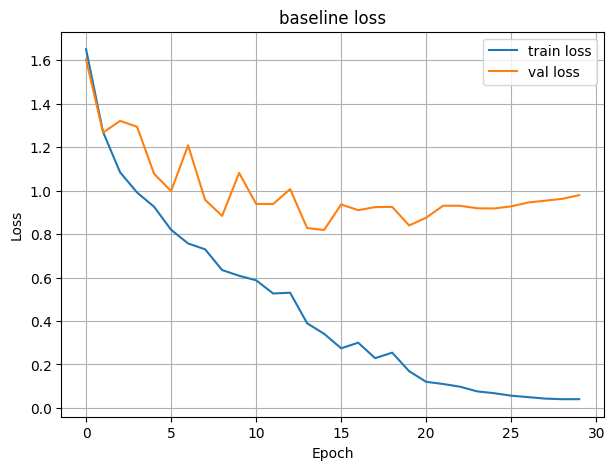

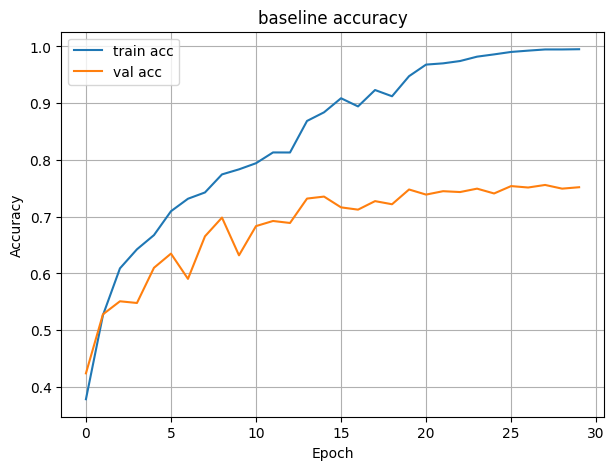

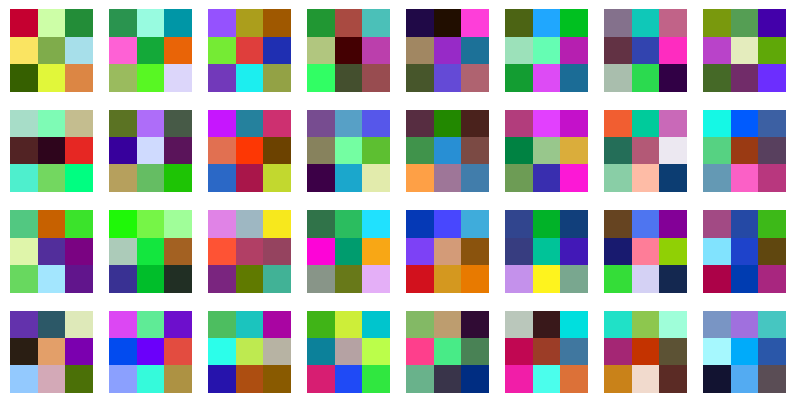

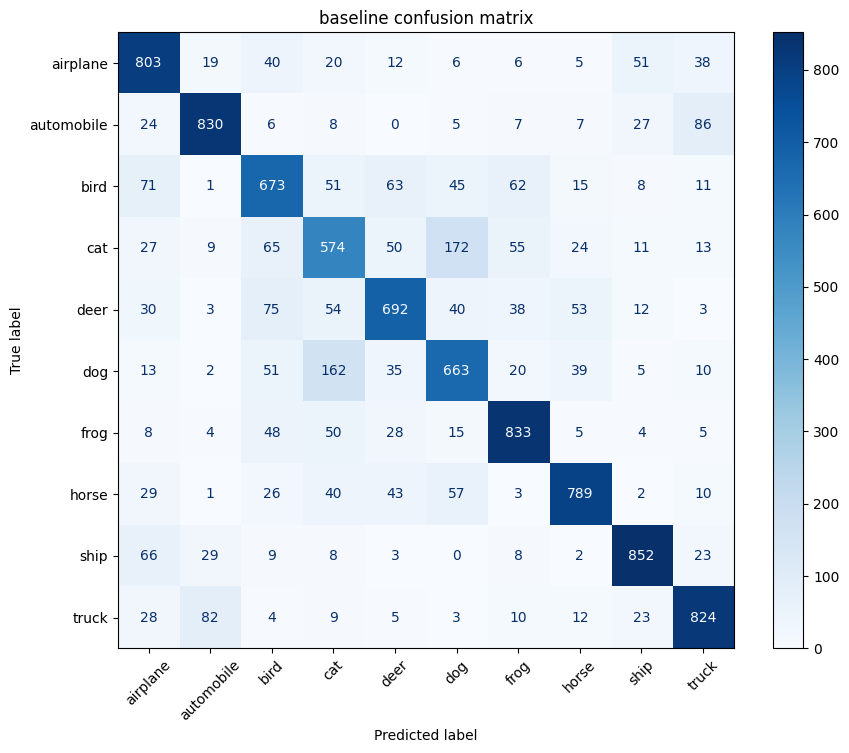


RUNNING: dropout_03
1 train loss 1.8135 train acc 0.3103 val loss 1.5259 val acc 0.432
2 train loss 1.4304 train acc 0.4682 val loss 1.4811 val acc 0.462
3 train loss 1.3233 train acc 0.5148 val loss 1.3861 val acc 0.513
4 train loss 1.1591 train acc 0.5827 val loss 1.1664 val acc 0.579
5 train loss 1.0466 train acc 0.6251 val loss 1.2584 val acc 0.555
6 train loss 1.0345 train acc 0.6365 val loss 1.1125 val acc 0.6175
7 train loss 0.9249 train acc 0.6746 val loss 1.0318 val acc 0.6285
8 train loss 0.854 train acc 0.6954 val loss 1.1729 val acc 0.611
9 train loss 0.8357 train acc 0.7043 val loss 1.0279 val acc 0.6575
10 train loss 0.7526 train acc 0.7369 val loss 0.9444 val acc 0.6565
11 train loss 0.7358 train acc 0.7441 val loss 1.2857 val acc 0.6035
12 train loss 0.7114 train acc 0.751 val loss 1.3014 val acc 0.6045
13 train loss 0.6696 train acc 0.7678 val loss 0.9318 val acc 0.698
14 train loss 0.6212 train acc 0.7883 val loss 0.9147 val acc 0.6745
15 train loss 0.6048 train acc 

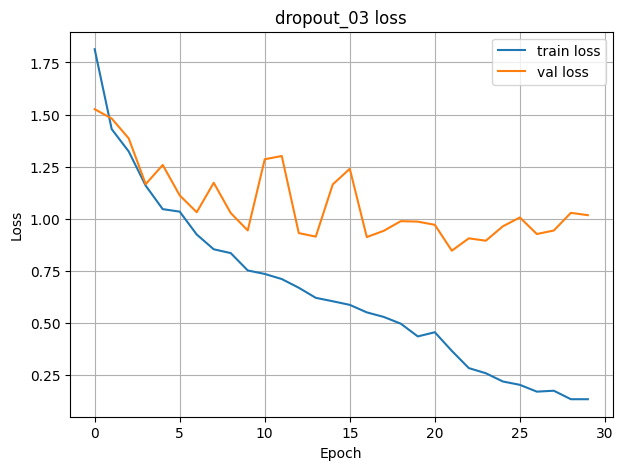

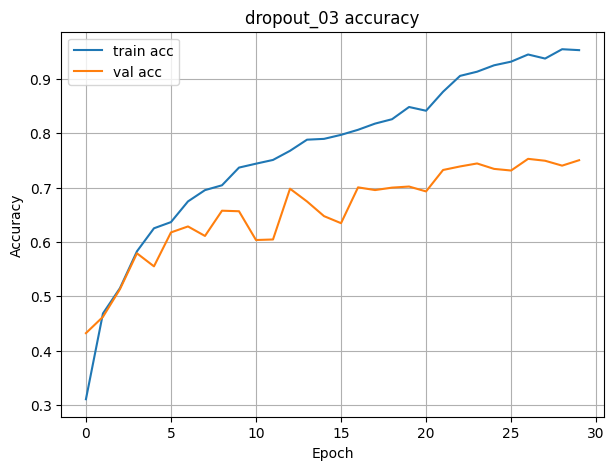

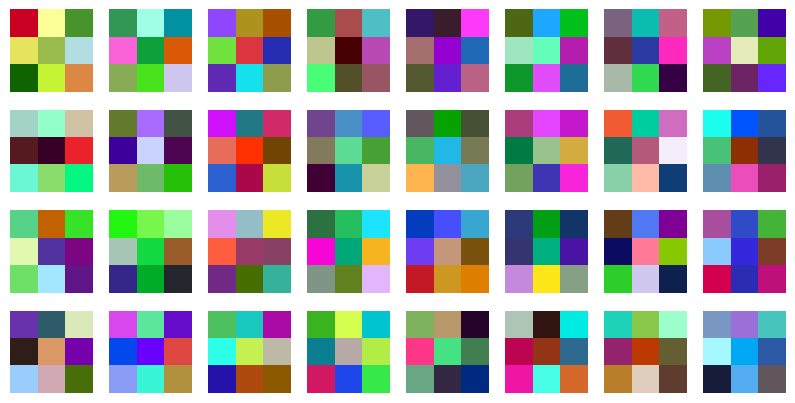

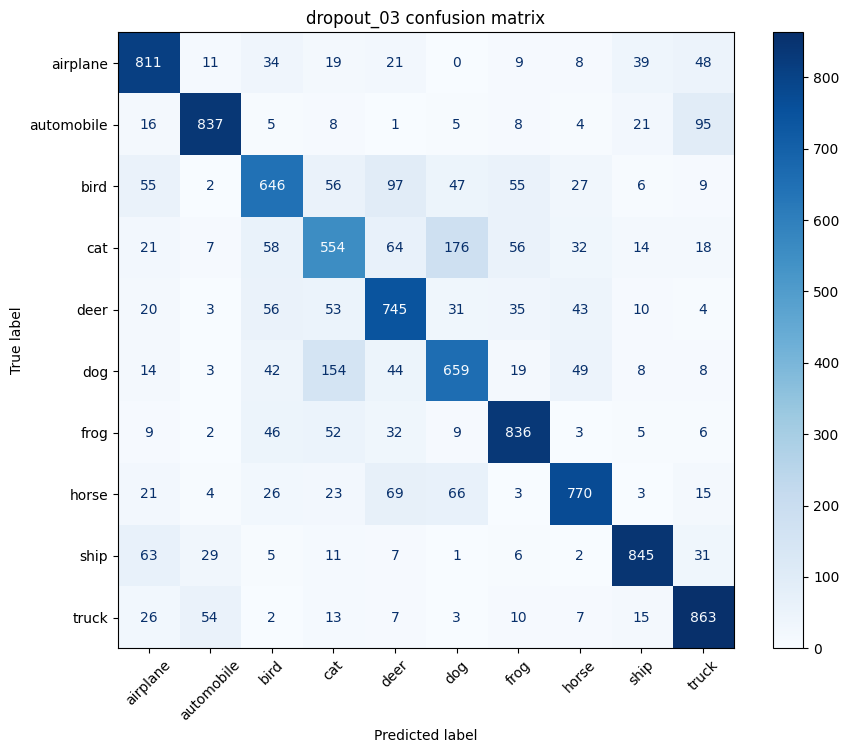


RUNNING: dropout_05
1 train loss 1.9871 train acc 0.2422 val loss 1.7042 val acc 0.361
2 train loss 1.617 train acc 0.3891 val loss 1.6054 val acc 0.4075
3 train loss 1.4852 train acc 0.4546 val loss 1.4999 val acc 0.434
4 train loss 1.3414 train acc 0.5082 val loss 1.3137 val acc 0.5305
5 train loss 1.2417 train acc 0.5556 val loss 1.2004 val acc 0.579
6 train loss 1.179 train acc 0.5772 val loss 1.4797 val acc 0.546
7 train loss 1.0759 train acc 0.619 val loss 1.317 val acc 0.5535
8 train loss 1.0349 train acc 0.6414 val loss 1.1393 val acc 0.6015
9 train loss 0.9958 train acc 0.6532 val loss 1.1854 val acc 0.589
10 train loss 0.9562 train acc 0.6676 val loss 1.0793 val acc 0.6305
11 train loss 0.9343 train acc 0.6731 val loss 1.2186 val acc 0.6055
12 train loss 0.868 train acc 0.7076 val loss 1.3317 val acc 0.592
13 train loss 0.8345 train acc 0.7127 val loss 0.9826 val acc 0.65
14 train loss 0.8073 train acc 0.7263 val loss 1.0296 val acc 0.648
15 train loss 0.8018 train acc 0.723

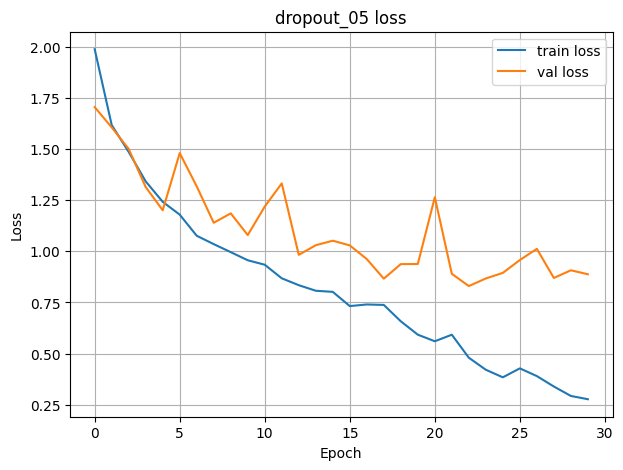

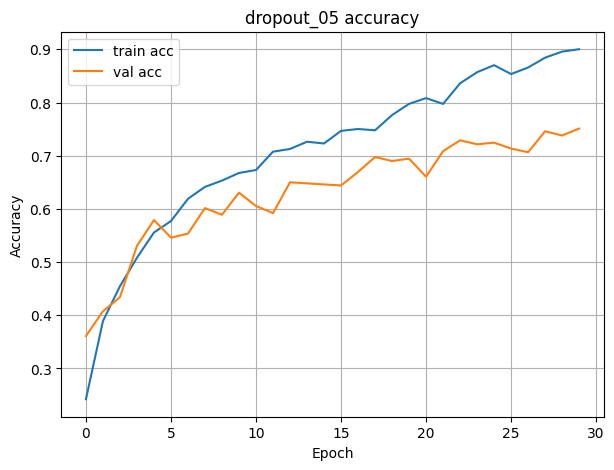

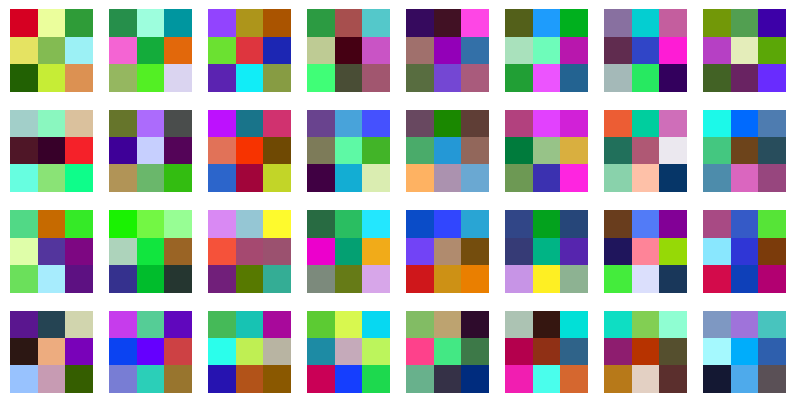

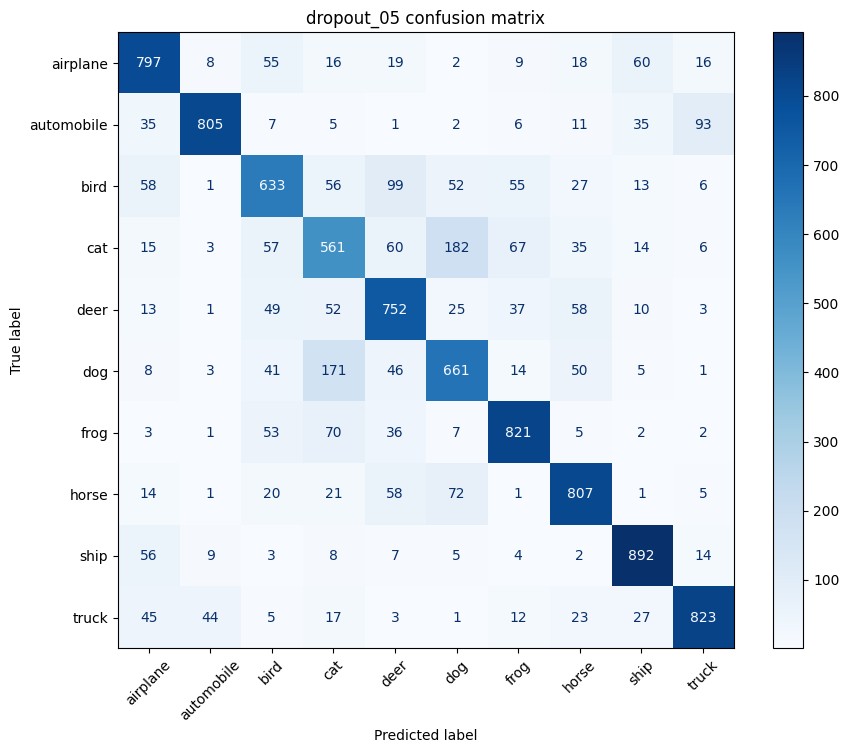


RUNNING: l2_bonus
1 train loss 1.6505 train acc 0.3792 val loss 1.5827 val acc 0.42
2 train loss 1.2679 train acc 0.5283 val loss 1.3383 val acc 0.5125
3 train loss 1.0806 train acc 0.6096 val loss 1.341 val acc 0.541
4 train loss 0.9818 train acc 0.6477 val loss 1.2125 val acc 0.5685
5 train loss 0.9153 train acc 0.6751 val loss 1.0333 val acc 0.6155
6 train loss 0.8089 train acc 0.7112 val loss 1.018 val acc 0.629
7 train loss 0.7414 train acc 0.74 val loss 1.1225 val acc 0.614
8 train loss 0.7332 train acc 0.7415 val loss 0.9632 val acc 0.661
9 train loss 0.6412 train acc 0.7708 val loss 0.9802 val acc 0.656
10 train loss 0.6034 train acc 0.7852 val loss 1.0746 val acc 0.634
11 train loss 0.5872 train acc 0.7969 val loss 1.0221 val acc 0.671
12 train loss 0.5387 train acc 0.8122 val loss 0.8483 val acc 0.6985
13 train loss 0.5221 train acc 0.8171 val loss 0.9216 val acc 0.6995
14 train loss 0.436 train acc 0.8476 val loss 0.8938 val acc 0.71
15 train loss 0.5243 train acc 0.8172 va

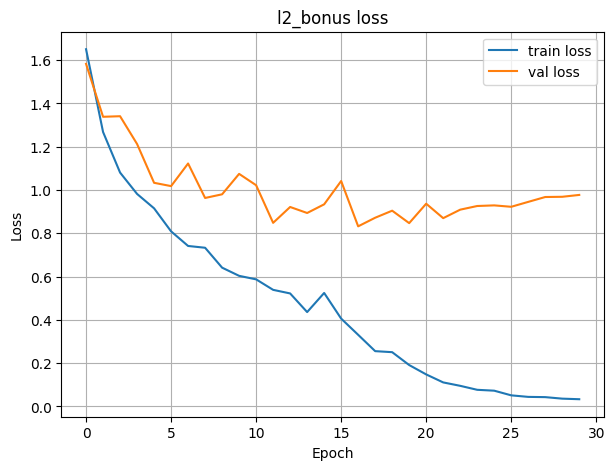

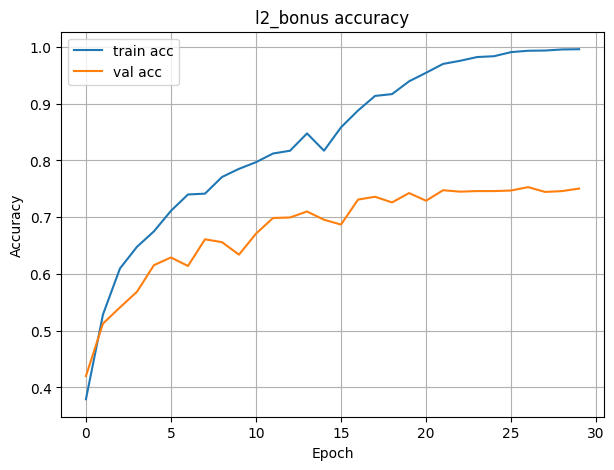

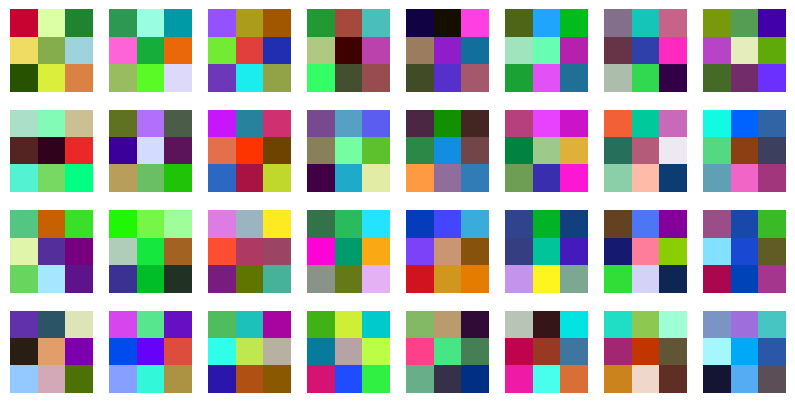

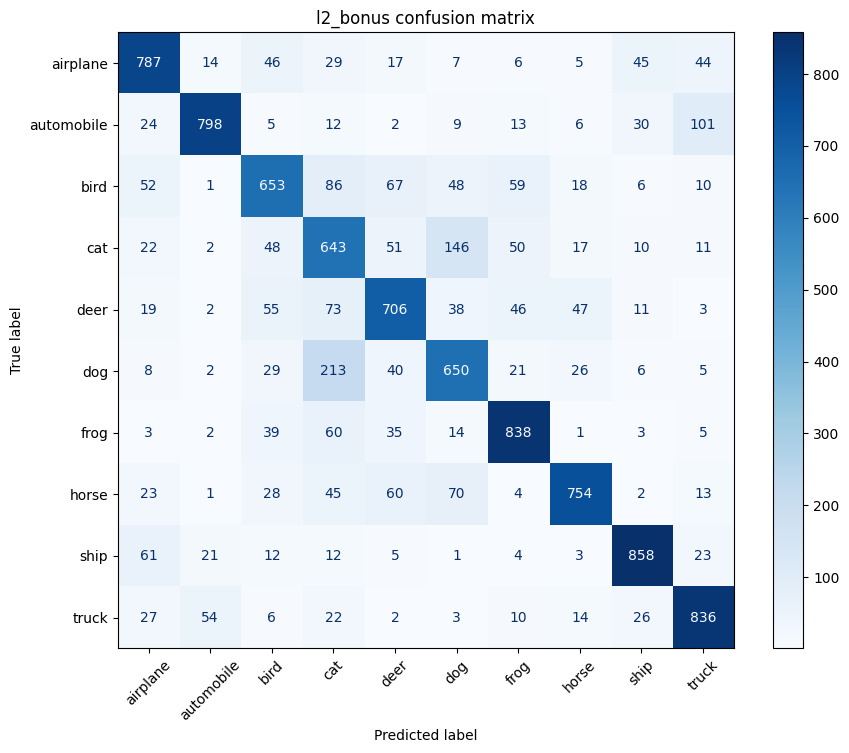

In [4]:
base_model, base_tl, base_vl, base_ta, base_va, base_info = train_model('baseline', 0.0, 0.0)
d03_model, d03_tl, d03_vl, d03_ta, d03_va, d03_info = train_model('dropout_03', 0.3, 0.0)
d05_model, d05_tl, d05_vl, d05_ta, d05_va, d05_info = train_model('dropout_05', 0.5, 0.0)
l2_model, l2_tl, l2_vl, l2_ta, l2_va, l2_info = train_model('l2_bonus', 0.0, 1e-4)

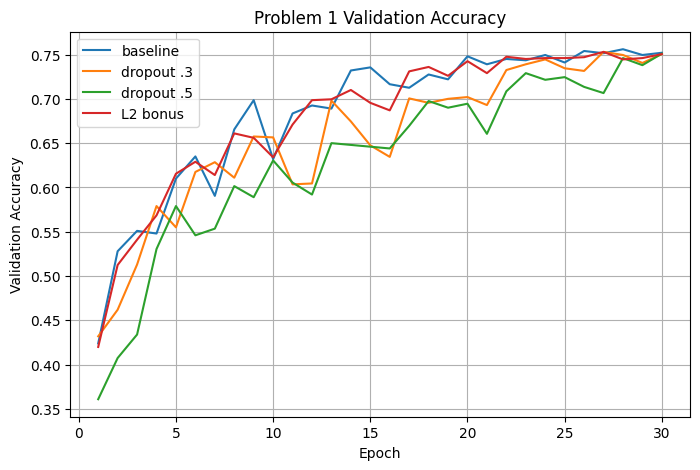

baseline {'seed': 42, 'epochs': 30, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'optimizer': 'AdamW', 'lr': 0.001, 'scheduler': 'ReduceLROnPlateau', 'dropout': 0.0, 'weight_decay': 0.0, 'params': 612042, 'test_acc': 0.7533, 'best_val_acc': 0.756, 'time': 571.9942402839661, 'hardware': 'CPU'}
dropout .3 {'seed': 42, 'epochs': 30, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'optimizer': 'AdamW', 'lr': 0.001, 'scheduler': 'ReduceLROnPlateau', 'dropout': 0.3, 'weight_decay': 0.0, 'params': 612042, 'test_acc': 0.7566, 'best_val_acc': 0.753, 'time': 570.7703633308411, 'hardware': 'CPU'}
dropout .5 {'seed': 42, 'epochs': 30, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'optimizer': 'AdamW', 'lr': 0.001, 'scheduler': 'ReduceLROnPlateau', 'dropout': 0.5, 'weight_decay': 0.0, 'params': 612042, 'test_acc': 0.7552, 'best_val_acc': 0.751, 'time': 547.0964744091034, 'hardware': 'CPU'}
L2 bonus {'seed': 42, 'epochs': 30, 'train_size': 10000, 'val_size': 2000, 

In [5]:
x = range(1, epochs + 1)
plt.figure(figsize=(8,5)); plt.plot(x,base_va,label='baseline'); plt.plot(x,d03_va,label='dropout .3'); plt.plot(x,d05_va,label='dropout .5'); plt.plot(x,l2_va,label='L2 bonus'); plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy'); plt.title('Problem 1 Validation Accuracy'); plt.legend(); plt.grid(); plt.savefig('Results_P1/val_acc_compare.png', dpi=200); plt.show()
print('baseline', base_info)
print('dropout .3', d03_info)
print('dropout .5', d05_info)
print('L2 bonus', l2_info)
print('Report note: fast_cpu=True used 10000 train and 2000 validation images because laptop CPU training was slow.')